## Runtime-budget experiment

User-requested target: approximately 30 minutes. Both architectures retain nine seeds, four optimizer passes, author-style loss, validation checkpoint criteria, and raw-weight ensemble construction. Training is shortened to 16/4/48 epochs; checkpoint warm-up is shortened from 64 to 4 epochs. This is a reduced-schedule extension, **not an exact original-paper training replication**. Runtime is an estimate, not a guarantee. Paper and historical replication comparisons are contextual benchmarks.


# 10 — Economic Regimes: Full-Schedule LSTM versus Transformer

## Process
1. Verify the six model return series saved by reduced-schedule Code 09: four historical replication models and the new matched nine-seed LSTM/Transformer pair.
2. Load the official monthly FRED/NBER recession indicator and cached Fama–French market excess returns.
3. Define recession/expansion labels descriptively. Define high/low volatility from the previous 12 market-return observations, with the threshold fixed at the training-period median.
4. Compare monthly Sharpe, mean return, volatility, and positive-month frequency within each test regime; report every regime sample size.
5. Plot regime Sharpe and the test factor paths with recession shading. Compare full-period train/validation/test Sharpe with paper and historical replication benchmarks.
6. Save labelled monthly returns, tables, figures, and answers to the questions below.

## Questions
**Q1.** Which architecture performs better during recessions versus expansions?

**Q2.** Does the relative performance change in high versus low market-volatility periods?

**Q3.** How do the regime findings relate to full-period Sharpe, the original replication, and the paper?

**Q4.** What can we conclude, and which limitations remain?

## Paper conventions and extension scope
The underlying models use the verified author training conventions from Code 08 reduced schedule. All Sharpe calculations use population standard deviation (`ddof=0`), consistent with the authors' utility, and the inherited normalized factor-return convention. The paper includes NBER shading when discussing its economic states; this Transformer-versus-LSTM regime comparison and the training-median volatility rule are **extensions**, not tables reproduced from the paper.

NBER labels are retrospective. [FRED USREC](https://fred.stlouisfed.org/series/USREC) marks the month after a peak through the trough; it is not a real-time trading signal. Volatility labels use lagged information and a training-only threshold, never a test median. [Kenneth French Data Library](https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/data_library.html) provides the market excess-return series, already cached by Code 07.

Regime-conditioned annualized Sharpe is √12 times conditional monthly Sharpe. It describes conditional return distributions, not an implementable strategy guaranteed to stay in that regime for a year. We do not concatenate nonconsecutive regime months into a drawdown or compounded-wealth path. Small recession samples and overlapping trailing volatility observations limit statistical interpretation. No test-based model tuning, regime-threshold selection, or causal claims are made.


## 1 — Paths and verified model inputs

In [1]:
from pathlib import Path
import json, hashlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

def find_root():
    for p in [Path.cwd().resolve(),*Path.cwd().resolve().parents]:
        if (p / "notebooks" / "08_reduced_schedule_comparison.ipynb").exists():return p
    raise FileNotFoundError("Start Jupyter inside the replication repository.")
ROOT=find_root()
SOURCE=ROOT / "results" / "rolling_oos_reduced_schedule" / "factors" / "all_model_test_factor_returns.csv"
FULL_TABLE=ROOT / "results" / "rolling_oos_reduced_schedule" / "tables" / "all_models_vs_paper_monthly_sharpe.csv"
REC_PATH=ROOT / "data" / "external" / "usrec_fred.csv"
MARKET_PATH=ROOT / "data" / "external" / "fama_french_3_monthly.csv"
OUT=ROOT / "results" / "regime_analysis"
for name in ["tables","figures","factors"]:(OUT/name).mkdir(parents=True,exist_ok=True)
returns=pd.read_csv(SOURCE,parse_dates=["date"]).set_index("date").sort_index()
TEST_DATES=pd.date_range("1992-01-01","2016-12-01",freq="MS")
assert pd.DatetimeIndex(returns.index).equals(TEST_DATES)
assert not returns.index.duplicated().any() and returns.shape==(300,6)
assert np.isfinite(returns.to_numpy()).all()
PAIR=["GAN–LSTM reduced schedule","GAN–Transformer reduced schedule"]
assert set(PAIR).issubset(returns.columns)
full_sharpe=pd.read_csv(FULL_TABLE,index_col="model")
display(full_sharpe)
print("Verified 300 test months and six model series.")


,source,train,validation,test
model,,,,
LS,Our saved model returns,2.029042,0.769588,0.406392
EN,Our saved model returns,1.125397,1.037838,0.411508
FFN,Our saved model returns,0.659724,0.851950,0.569521
GAN–LSTM original,Our saved model returns,2.223515,1.185409,0.611888
GAN–LSTM reduced schedule,Our saved model returns,1.307557,0.750136,0.459293
GAN–Transformer reduced schedule,Our saved model returns,1.049036,0.588745,0.304477
LS (paper),Published benchmark recorded in Code 07,1.800000,0.580000,0.420000
EN (paper),Published benchmark recorded in Code 07,1.370000,1.150000,0.500000
FFN (paper),Published benchmark recorded in Code 07,0.450000,0.420000,0.440000


Verified 300 test months and six model series.


## 2 — Recession and prospective volatility labels

In [2]:
rec=pd.read_csv(REC_PATH,parse_dates=["observation_date"]).rename(columns={"observation_date":"date","USREC":"recession"}).set_index("date")
rec=rec.sort_index()
assert not rec.index.duplicated().any()
assert rec.recession.isin([0,1]).all()
market=pd.read_csv(MARKET_PATH,parse_dates=["date"]).set_index("date").sort_index()["Mkt-RF"]
assert not market.index.duplicated().any()
expected_market=pd.date_range(market.index.min(),market.index.max(),freq="MS")
assert market.index.equals(expected_market)
assert np.isfinite(market.to_numpy()).all()
lagged_vol=market.rolling(12,min_periods=12).std(ddof=0).shift(1)
training_vol=lagged_vol.loc["1967-01-01":"1986-12-01"].dropna()
assert len(training_vol)==240
threshold=float(training_vol.median())
labels=pd.DataFrame(index=TEST_DATES)
labels["recession"]=rec.reindex(TEST_DATES).recession
labels["lagged_market_volatility"]=lagged_vol.reindex(TEST_DATES)
assert labels.notna().all().all()
labels["business_cycle"]=np.where(labels.recession==1,"Recession","Expansion")
labels["volatility_regime"]=np.where(labels.lagged_market_volatility>threshold,"High volatility","Low volatility")
# Future returns must not alter earlier volatility or the training threshold.
changed=market.copy();changed.loc["2005-01-01":]+=.01
changed_vol=changed.rolling(12,min_periods=12).std(ddof=0).shift(1)
pd.testing.assert_series_equal(lagged_vol.loc[:"2005-01-01"],changed_vol.loc[:"2005-01-01"])
assert np.isclose(threshold,changed_vol.loc["1967-01-01":"1986-12-01"].median())
assert labels.business_cycle.value_counts().sum()==300
assert labels.volatility_regime.value_counts().sum()==300
labels.to_csv(OUT / "tables" / "monthly_regime_labels.csv",index_label="date")
inventory=pd.concat([labels.business_cycle.value_counts().rename("months"),labels.volatility_regime.value_counts().rename("months")]).rename_axis("regime").reset_index()
display(inventory)
print(f"Training-median lagged market volatility threshold: {threshold:.6f} monthly ({threshold*np.sqrt(12):.2%} annualized).")
manifest={"input_sha256":{str(p.relative_to(ROOT)):hashlib.sha256(p.read_bytes()).hexdigest() for p in [SOURCE,FULL_TABLE,REC_PATH,MARKET_PATH]},
    "volatility_window":12,"volatility_lag":1,"threshold":threshold,"threshold_sample":"1967–1986 training only",
    "sharpe_ddof":0,"recession_source":"https://fred.stlouisfed.org/series/USREC","recession_convention":"month following peak through trough"}
(OUT / "manifest.json").write_text(json.dumps(manifest,indent=2))


,regime,months
0,Expansion,274
1,Recession,26
2,Low volatility,177
3,High volatility,123


Training-median lagged market volatility threshold: 0.039783 monthly (13.78% annualized).


848

## 3 — Regime performance for every model

In [3]:
def regime_stats(r):
    r=np.asarray(r,dtype=float);vol=r.std(ddof=0)
    return {"months":len(r),"mean_monthly":r.mean(),"volatility_monthly":vol,
        "monthly_sharpe":r.mean()/vol if vol>0 else np.nan,
        "annualized_sharpe":np.sqrt(12)*r.mean()/vol if vol>0 else np.nan,
        "minimum_month":r.min(),"positive_month_fraction":(r>0).mean()}
rows=[]
for family in ["business_cycle","volatility_regime"]:
    for regime in labels[family].unique():
        mask=labels[family]==regime
        for model in returns:
            rows.append({"family":family,"regime":regime,"model":model,**regime_stats(returns.loc[mask,model])})
regime_performance=pd.DataFrame(rows)
assert len(regime_performance)==24
assert np.isfinite(regime_performance.select_dtypes(include="number").to_numpy()).all()
regime_performance.to_csv(OUT / "tables" / "regime_performance_all_models.csv",index=False)
regime_table=regime_performance.pivot(index="model",columns="regime",values="monthly_sharpe")
display(regime_table.round(4))
regime_table.to_csv(OUT / "tables" / "regime_monthly_sharpe_comparison.csv")
# Weighted group means must reconstruct each model's full-test mean.
for family in ["business_cycle","volatility_regime"]:
    subset=regime_performance[regime_performance.family==family]
    for model in returns:
        group=subset[subset.model==model]
        assert group.months.sum()==300
        assert np.isclose(np.average(group.mean_monthly,weights=group.months),returns[model].mean())
# Joint regimes report the smaller sample sizes explicitly.
joint=[]
for (cycle,vol),dates in labels.groupby(["business_cycle","volatility_regime"]).groups.items():
    for model in returns:
        joint.append({"business_cycle":cycle,"volatility_regime":vol,"model":model,**regime_stats(returns.loc[dates,model])})
joint_performance=pd.DataFrame(joint)
display(joint_performance[joint_performance.model.isin(PAIR)])
joint_performance.to_csv(OUT / "tables" / "joint_regime_performance.csv",index=False)


regime,Expansion,High volatility,Low volatility,Recession
model,,,,
EN,0.4450,0.2707,0.7192,0.2542
FFN,0.5696,0.5370,0.6960,0.5696
GAN–LSTM original,0.6369,0.4799,0.8413,0.4553
GAN–LSTM reduced schedule,0.4826,0.4174,0.5494,0.2638
GAN–Transformer reduced schedule,0.3695,0.1775,0.5308,-0.0713
LS,0.4071,0.3501,0.5250,0.4038


,business_cycle,volatility_regime,model,months,mean_monthly,volatility_monthly,monthly_sharpe,annualized_sharpe,minimum_month,positive_month_fraction
4,Expansion,High volatility,GAN–LSTM reduced schedule,106,0.005945,0.014533,0.409071,1.417062,-0.078912,0.688679
5,Expansion,High volatility,GAN–Transformer reduced schedule,106,0.004641,0.017546,0.264529,0.916354,-0.081517,0.679245
10,Expansion,Low volatility,GAN–LSTM reduced schedule,168,0.004875,0.007887,0.618042,2.140960,-0.029399,0.761905
11,Expansion,Low volatility,GAN–Transformer reduced schedule,168,0.004861,0.008848,0.549387,1.903131,-0.020795,0.690476
16,Recession,High volatility,GAN–LSTM reduced schedule,17,0.006099,0.012711,0.479845,1.662233,-0.028692,0.705882
17,Recession,High volatility,GAN–Transformer reduced schedule,17,-0.004953,0.022923,-0.216053,-0.748429,-0.038718,0.529412
22,Recession,Low volatility,GAN–LSTM reduced schedule,9,-0.001608,0.012029,-0.133687,-0.463106,-0.021937,0.666667
23,Recession,Low volatility,GAN–Transformer reduced schedule,9,0.005067,0.013969,0.362726,1.256521,-0.020175,0.777778


## 4 — Figures: regime Sharpe and recession-shaded factor paths

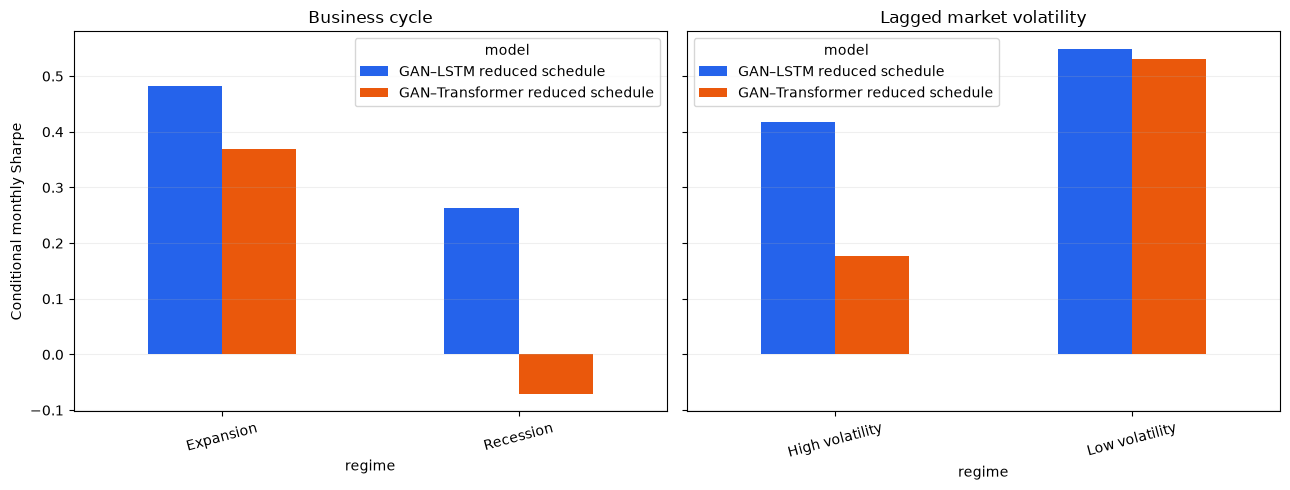

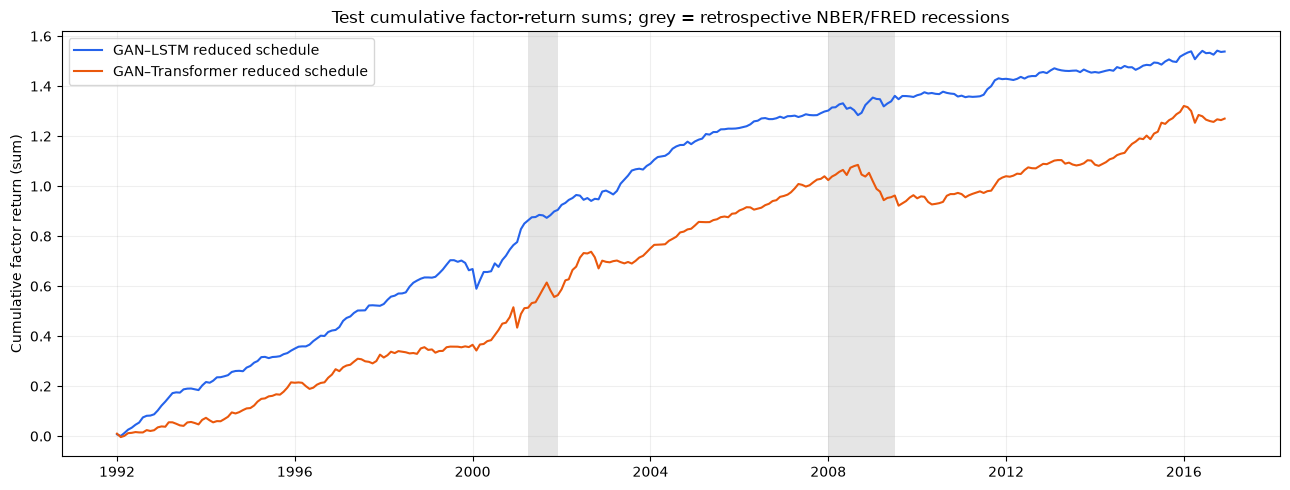

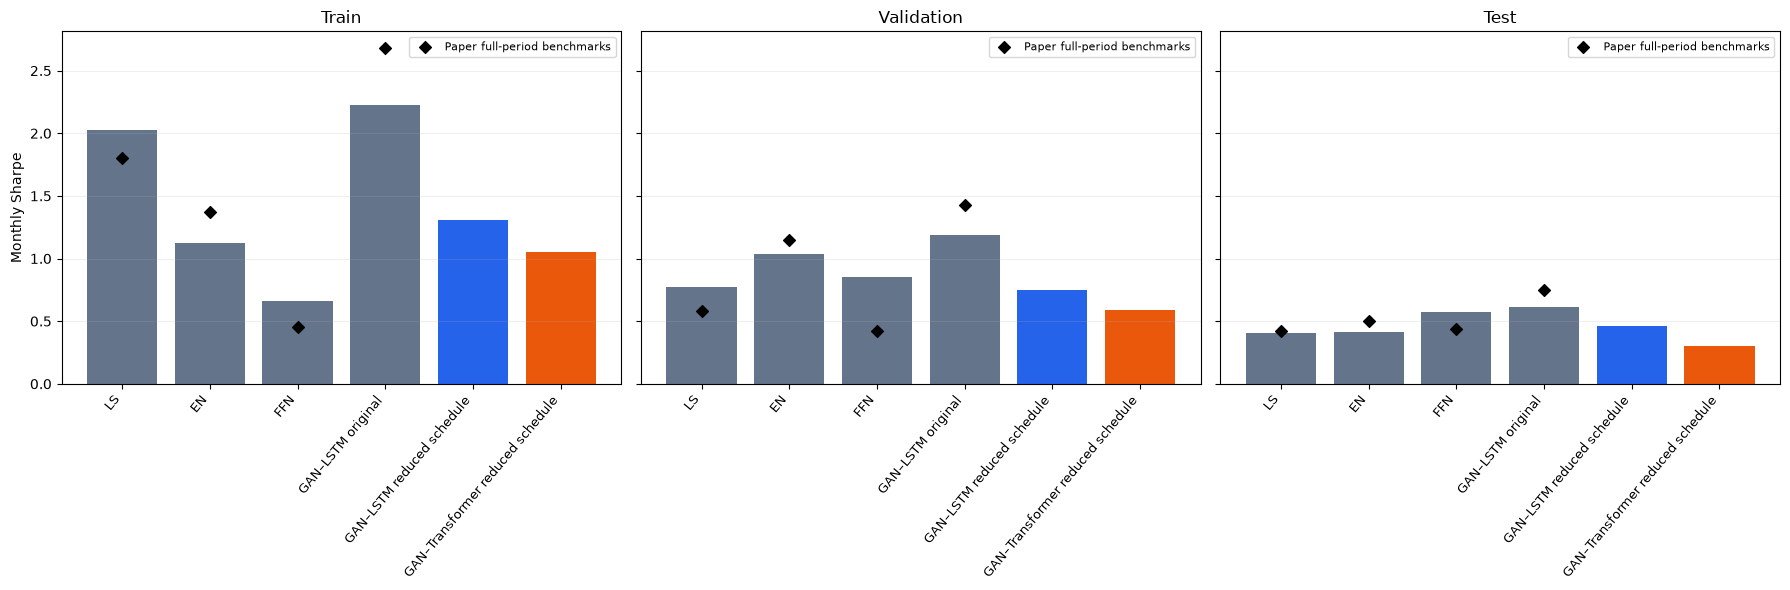

In [4]:
fig,axes=plt.subplots(1,2,figsize=(13,5),sharey=True)
for ax,family in zip(axes,["business_cycle","volatility_regime"]):
    table=regime_performance[(regime_performance.family==family)&(regime_performance.model.isin(PAIR))].pivot(index="regime",columns="model",values="monthly_sharpe")[PAIR]
    table.plot.bar(ax=ax,rot=15,color=["#2563eb","#ea580c"])
    ax.set_title("Business cycle" if family=="business_cycle" else "Lagged market volatility")
    ax.set_ylabel("Conditional monthly Sharpe");ax.grid(axis="y",alpha=.2)
fig.tight_layout();fig.savefig(OUT / "figures" / "regime_sharpe.png",dpi=150);plt.show()
fig,ax=plt.subplots(figsize=(13,5))
for model,color in zip(PAIR,["#2563eb","#ea580c"]):
    ax.plot(returns.index,returns[model].cumsum(),label=model,color=color)
for date in labels.index[labels.recession==1]:
    ax.axvspan(date,date+pd.offsets.MonthBegin(1),color="grey",alpha=.2,linewidth=0)
ax.set_title("Test cumulative factor-return sums; grey = retrospective NBER/FRED recessions")
ax.set_ylabel("Cumulative factor return (sum)");ax.legend();ax.grid(alpha=.2)
fig.tight_layout();fig.savefig(OUT / "figures" / "recession_shaded_factor_paths.png",dpi=150);plt.show()
# Full-period figures keep paper benchmarks separate from regime-conditioned metrics.
ours=full_sharpe.loc[returns.columns,["train","validation","test"]]
fig,axes=plt.subplots(1,3,figsize=(18,6),sharey=True)
for ax,split in zip(axes,["train","validation","test"]):
    ax.bar(np.arange(6),ours[split],color=["#64748b"]*4+["#2563eb","#ea580c"])
    paper=full_sharpe.loc[["LS (paper)","EN (paper)","FFN (paper)","GAN–LSTM (paper)"],split]
    ax.scatter(np.arange(4),paper,color="black",marker="D",label="Paper full-period benchmarks",zorder=3)
    ax.set_xticks(np.arange(6),returns.columns,rotation=50,ha="right",fontsize=9);ax.set_title(split.title());ax.legend(fontsize=8);ax.grid(axis="y",alpha=.2)
axes[0].set_ylabel("Monthly Sharpe")
fig.tight_layout();fig.savefig(OUT / "figures" / "train_validation_test_sharpe.png",dpi=150);plt.show()


## 5 — Results, answers, and relationship to Codes 08–09

In [5]:
pair_table=regime_table.loc[PAIR]
delta=pair_table.loc[PAIR[1]]-pair_table.loc[PAIR[0]]
summary=f"""### Executed results and answers

**Q1 — Business cycle:** Transformer minus LSTM conditional monthly Sharpe is **{delta['Recession']:+.4f}** in recessions and **{delta['Expansion']:+.4f}** in expansions. A positive difference means the Transformer is higher. There are **{int((labels.recession==1).sum())} recession months** and **{int((labels.recession==0).sum())} expansion months**. The short recession sample is especially sensitive to a few observations.

**Q2 — Market volatility:** The difference is **{delta['High volatility']:+.4f}** in high-volatility months and **{delta['Low volatility']:+.4f}** in low-volatility months. Labels use previous-12-month market volatility and the fixed training median **{threshold:.6f}**. Neither current/future market returns nor test-distribution thresholds define prospective volatility labels.

**Q3 — Full-period context:** Code 08 reduced schedule compares the architectures under matched author conventions; Code 09 shows how their test performance changes across rolling windows; Code 10 groups that same realized performance by economic labels. The saved train/validation/test table compares all models with the original paper. Published unconditional full-test Sharpe is **not** a paper recession or high-volatility benchmark: the paper does not supply a corresponding Transformer/regime table.

**Q4 — Interpretation:** Regime results describe associations with economic conditions, not a causal mechanism, an independent significance test, or a regime-timing strategy. NBER labels are retrospective. The model and regime rules remain fixed across test months. Nine seeds reduce initialization dependence but do not create nine independent market histories. The inherited return convention, omitted trading costs, framework differences from TensorFlow, and lack of the original full hyperparameter search remain relevant limitations.

All model returns, monthly labels, regime sample counts, performance tables, source hashes, and figures are saved. These three notebooks together form an architecture comparison, temporal diagnostics, and economic interpretation; their extensions are distinguished from the published replication.
"""
display(pair_table.round(4));display(Markdown(summary))
(OUT / "results_and_answers.txt").write_text(summary+"\n\nConditional monthly Sharpe\n"+regime_table.to_string())
joined=returns.join(labels)
assert len(joined)==300 and joined.notna().all().all()
joined.to_csv(OUT / "factors" / "regime_labelled_model_returns.csv",index_label="date")
inventory.to_csv(OUT / "tables" / "regime_sample_sizes.csv",index=False)
print("CODE 10 COMPLETE: verified labels, regime results, answers, tables, and figures saved.")


regime,Expansion,High volatility,Low volatility,Recession
model,,,,
GAN–LSTM reduced schedule,0.4826,0.4174,0.5494,0.2638
GAN–Transformer reduced schedule,0.3695,0.1775,0.5308,-0.0713


### Executed results and answers

**Q1 — Business cycle:** Transformer minus LSTM conditional monthly Sharpe is **-0.3351** in recessions and **-0.1131** in expansions. A positive difference means the Transformer is higher. There are **26 recession months** and **274 expansion months**. The short recession sample is especially sensitive to a few observations.

**Q2 — Market volatility:** The difference is **-0.2399** in high-volatility months and **-0.0186** in low-volatility months. Labels use previous-12-month market volatility and the fixed training median **0.039783**. Neither current/future market returns nor test-distribution thresholds define prospective volatility labels.

**Q3 — Full-period context:** Code 08 reduced schedule compares the architectures under matched author conventions; Code 09 shows how their test performance changes across rolling windows; Code 10 groups that same realized performance by economic labels. The saved train/validation/test table compares all models with the original paper. Published unconditional full-test Sharpe is **not** a paper recession or high-volatility benchmark: the paper does not supply a corresponding Transformer/regime table.

**Q4 — Interpretation:** Regime results describe associations with economic conditions, not a causal mechanism, an independent significance test, or a regime-timing strategy. NBER labels are retrospective. The model and regime rules remain fixed across test months. Nine seeds reduce initialization dependence but do not create nine independent market histories. The inherited return convention, omitted trading costs, framework differences from TensorFlow, and lack of the original full hyperparameter search remain relevant limitations.

All model returns, monthly labels, regime sample counts, performance tables, source hashes, and figures are saved. These three notebooks together form an architecture comparison, temporal diagnostics, and economic interpretation; their extensions are distinguished from the published replication.


CODE 10 COMPLETE: verified labels, regime results, answers, tables, and figures saved.


## Saved run conclusions

### Executed results and answers

**Q1 — Business cycle:** Transformer minus LSTM conditional monthly Sharpe is **-0.3351** in recessions and **-0.1131** in expansions. A positive difference means the Transformer is higher. There are **26 recession months** and **274 expansion months**. The short recession sample is especially sensitive to a few observations.

**Q2 — Market volatility:** The difference is **-0.2399** in high-volatility months and **-0.0186** in low-volatility months. Labels use previous-12-month market volatility and the fixed training median **0.039783**. Neither current/future market returns nor test-distribution thresholds define prospective volatility labels.

**Q3 — Full-period context:** Code 08 reduced schedule compares the architectures under matched author conventions; Code 09 shows how their test performance changes across rolling windows; Code 10 groups that same realized performance by economic labels. The saved train/validation/test table compares all models with the original paper. Published unconditional full-test Sharpe is **not** a paper recession or high-volatility benchmark: the paper does not supply a corresponding Transformer/regime table.

**Q4 — Interpretation:** Regime results describe associations with economic conditions, not a causal mechanism, an independent significance test, or a regime-timing strategy. NBER labels are retrospective. The model and regime rules remain fixed across test months. Nine seeds reduce initialization dependence but do not create nine independent market histories. The inherited return convention, omitted trading costs, framework differences from TensorFlow, and lack of the original full hyperparameter search remain relevant limitations.

All model returns, monthly labels, regime sample counts, performance tables, source hashes, and figures are saved. These three notebooks together form an architecture comparison, temporal diagnostics, and economic interpretation; their extensions are distinguished from the published replication.


Conditional monthly Sharpe
regime                            Expansion  High volatility  Low volatility  Recession
model                                                                                  
EN                                 0.445040         0.270670        0.719193   0.254153
FFN                                0.569644         0.536982        0.695996   0.569607
GAN–LSTM original                  0.636939         0.479894        0.841285   0.455282
GAN–LSTM reduced schedule          0.482550         0.417369        0.549426   0.263809
GAN–Transformer reduced schedule   0.369464         0.177494        0.530793  -0.071265
LS                                 0.407070         0.350117        0.525039   0.403751

## Additional comparisons and interpretation

This section uses saved results and does not retrain any models.

### Regime comparison with sample sizes

| family | regime | months | lstm_monthly_sharpe | transformer_monthly_sharpe | transformer_minus_lstm | share_of_test_months |
| --- | --- | --- | --- | --- | --- | --- |
| business_cycle | Expansion | 274.000 | 0.483 | 0.369 | -0.113 | 0.913 |
| business_cycle | Recession | 26.000 | 0.264 | -0.071 | -0.335 | 0.087 |
| volatility_regime | High volatility | 123.000 | 0.417 | 0.177 | -0.240 | 0.410 |
| volatility_regime | Low volatility | 177.000 | 0.549 | 0.531 | -0.019 | 0.590 |

### Separate returns from risk

| regime | model | months | mean_monthly | volatility_monthly | annualized_sharpe | minimum_month | positive_month_fraction |
| --- | --- | --- | --- | --- | --- | --- | --- |
| Expansion | GAN–LSTM reduced schedule | 274.000 | 0.005 | 0.011 | 1.672 | -0.079 | 0.734 |
| Expansion | GAN–Transformer reduced schedule | 274.000 | 0.005 | 0.013 | 1.280 | -0.082 | 0.686 |
| Recession | GAN–LSTM reduced schedule | 26.000 | 0.003 | 0.013 | 0.914 | -0.029 | 0.692 |
| Recession | GAN–Transformer reduced schedule | 26.000 | -0.001 | 0.021 | -0.247 | -0.039 | 0.615 |
| High volatility | GAN–LSTM reduced schedule | 123.000 | 0.006 | 0.014 | 1.446 | -0.079 | 0.691 |
| High volatility | GAN–Transformer reduced schedule | 123.000 | 0.003 | 0.019 | 0.615 | -0.082 | 0.659 |
| Low volatility | GAN–LSTM reduced schedule | 177.000 | 0.005 | 0.008 | 1.903 | -0.029 | 0.757 |
| Low volatility | GAN–Transformer reduced schedule | 177.000 | 0.005 | 0.009 | 1.839 | -0.021 | 0.695 |

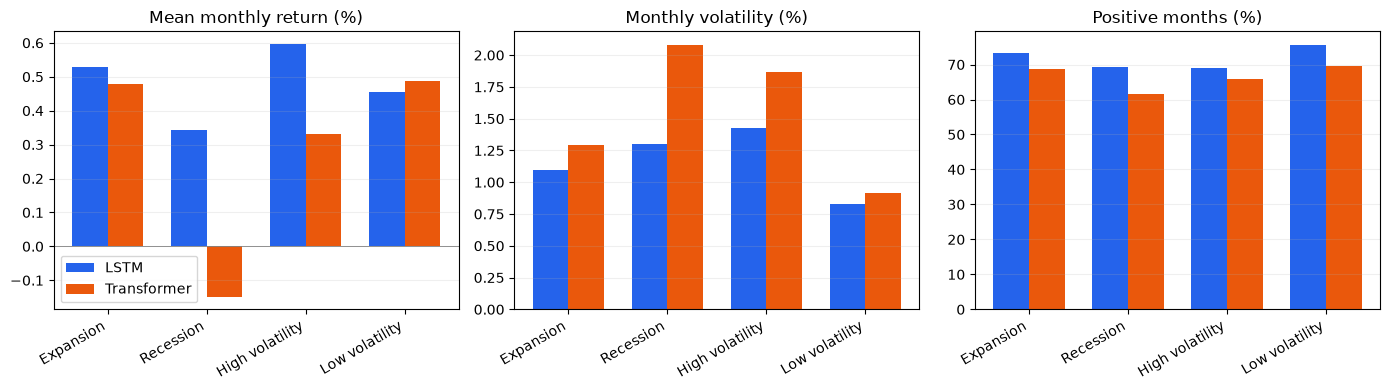

### What regime Sharpe means

Each conditional Sharpe uses only the monthly returns carrying that regime label. It divides their mean by their standard deviation (ddof=0). These months can be separated in time: they are not a continuous holding period. Conditional annualized Sharpe is monthly Sharpe × √12 for scale comparison, not a simulated regime-timing return.

The return/risk table and figure help explain whether a Sharpe gap accompanies weaker average returns, greater volatility, or both. Positive-month frequency adds another view, but a model can win frequently and still lose money through a few large losses. The minimum monthly return describes one observed extreme, not an estimated future risk limit.

Business-cycle labels divide the 300 test months into 274 expansion months and only 26 recession months. Volatility labels form a separate partition; business-cycle and volatility rows must not be added together. Recession estimates have a much smaller sample, so differences should not be treated as equally precise across groups.

NBER recession labels are retrospective. Volatility labels use lagged market volatility and a training-calibrated threshold. Neither model's own volatility determines the market regimes. Joint regime tables provide additional context but can have even smaller samples.

The paper's 0.750 full-test GAN Sharpe is an unconditional benchmark, not a recession or high-volatility Sharpe. A valid paper-regime comparison requires the authors' monthly return series and identical labels. These results explain where our reduced-schedule models differ; they do not establish causality or a trading rule.


1649

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
ROOT = Path.cwd()
if not (ROOT / 'results').exists(): ROOT = ROOT.parent
assert (ROOT / 'results').exists()
def mdtable(df):
    d=df.copy()
    for col in d.select_dtypes(include='number'): d[col]=d[col].map(lambda x: f'{x:.3f}')
    return '| '+' | '.join(map(str,d.columns))+' |\n| '+' | '.join(['---']*len(d.columns))+' |\n'+'\n'.join('| '+' | '.join(map(str,row))+' |' for row in d.itertuples(index=False,name=None))

out=ROOT/'results/regime_analysis'
reg=pd.read_csv(out/'tables/regime_performance_all_models.csv')
pair=reg[reg.model.isin(['GAN–LSTM reduced schedule','GAN–Transformer reduced schedule'])].copy()
p=pair.pivot(index=['family','regime','months'],columns='model',values='monthly_sharpe').reset_index()
p.columns=['family','regime','months','lstm_monthly_sharpe','transformer_monthly_sharpe']
p['transformer_minus_lstm']=p.transformer_monthly_sharpe-p.lstm_monthly_sharpe
p['share_of_test_months']=p.months/300
p.to_csv(out/'tables/explanation_regime_gaps_and_samples.csv',index=False)
display(Markdown('### Regime comparison with sample sizes\n\n'+mdtable(p)))
risk=pair[['regime','model','months','mean_monthly','volatility_monthly','annualized_sharpe','minimum_month','positive_month_fraction']].copy()
risk.to_csv(out/'tables/explanation_regime_return_risk.csv',index=False)
display(Markdown('### Separate returns from risk\n\n'+mdtable(risk)))
fig,axes=plt.subplots(1,3,figsize=(14,4))
order=['Expansion','Recession','High volatility','Low volatility']
for ax,metric,title in zip(axes,['mean_monthly','volatility_monthly','positive_month_fraction'],['Mean monthly return (%)','Monthly volatility (%)','Positive months (%)']):
    for offset,model,color,label in [(-.18,'GAN–LSTM reduced schedule','#2563eb','LSTM'),(.18,'GAN–Transformer reduced schedule','#ea580c','Transformer')]:
        vals=pair[pair.model==model].set_index('regime').loc[order,metric]*100
        ax.bar(np.arange(4)+offset,vals,width=.36,color=color,label=label)
    ax.set_xticks(np.arange(4),order,rotation=30,ha='right');ax.set_title(title);ax.axhline(0,color='grey',linewidth=.6);ax.grid(axis='y',alpha=.2)
axes[0].legend();fig.tight_layout();fig.savefig(out/'figures/explanation_regime_return_risk.png',dpi=160);plt.show()
text='''### What regime Sharpe means

Each conditional Sharpe uses only the monthly returns carrying that regime label. It divides their mean by their standard deviation (ddof=0). These months can be separated in time: they are not a continuous holding period. Conditional annualized Sharpe is monthly Sharpe × √12 for scale comparison, not a simulated regime-timing return.

The return/risk table and figure help explain whether a Sharpe gap accompanies weaker average returns, greater volatility, or both. Positive-month frequency adds another view, but a model can win frequently and still lose money through a few large losses. The minimum monthly return describes one observed extreme, not an estimated future risk limit.

Business-cycle labels divide the 300 test months into 274 expansion months and only 26 recession months. Volatility labels form a separate partition; business-cycle and volatility rows must not be added together. Recession estimates have a much smaller sample, so differences should not be treated as equally precise across groups.

NBER recession labels are retrospective. Volatility labels use lagged market volatility and a training-calibrated threshold. Neither model's own volatility determines the market regimes. Joint regime tables provide additional context but can have even smaller samples.

The paper's 0.750 full-test GAN Sharpe is an unconditional benchmark, not a recession or high-volatility Sharpe. A valid paper-regime comparison requires the authors' monthly return series and identical labels. These results explain where our reduced-schedule models differ; they do not establish causality or a trading rule.
'''
display(Markdown(text));(out/'explanation_addendum.md').write_text(text)
